# NumPy 3 — statistics, linear algebra, random numbers

Every section starts with numbers small enough to check by hand.

**What's in here**
- `mean`, `std`, `var` and the `ddof` difference between NumPy and pandas
- NaN-aware reductions, percentiles
- correlation and covariance
- `np.polyfit` for a trend line
- `@` vs `*`
- OLS three ways on a 4-row example, then sklearn
- `inv`, `solve`, `norm`
- random numbers, bootstrap, a Monte Carlo AR(1)
- NumPy positional vs pandas aligned

In [1]:
import numpy as np
import pandas as pd

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.width", 120)

df = pd.read_csv("../data/hourly_power_clean.csv", parse_dates=["time"])
cons = df["consumption_mwh"].to_numpy()
temp = df["temp_c"].to_numpy()
price = df["price_eur_mwh"].to_numpy()
wind = df["wind_ms"].to_numpy()

## 1. Mean, std, var — and `ddof`

Three values: 2, 4, 6. Mean is 4. Squared deviations: 4, 0, 4 → sum 8.

In [2]:
x = np.array([2., 4., 6.])
print(x.mean())

4.0


NumPy `std` divides by n (= 3): sqrt(8/3) = 1.633.
pandas `std` divides by n − 1 (= 2): sqrt(8/2) = 2.0.

In [3]:
print("numpy  std, ddof=0:", x.std())
print("numpy  std, ddof=1:", x.std(ddof=1))
print("pandas std, default ddof=1:", pd.Series(x).std())

numpy  std, ddof=0: 1.632993161855452
numpy  std, ddof=1: 2.0
pandas std, default ddof=1: 2.0


**Interview check:** "Your volatility number doesn't match mine." → check `ddof`.

## 2. NaN-aware reductions

One NaN poisons `mean`. The `nan*` versions skip it.

In [4]:
x = np.array([1., 2., np.nan, 4.])
print(x.mean())
print(np.nanmean(x))

nan
2.3333333333333335


**Pitfall:** `nansum` of all-NaN is 0, not NaN.

In [5]:
print(np.nansum([np.nan, np.nan]))

0.0


pandas skips NaN by default.

In [6]:
pd.Series(x).mean()

2.3333333333333335

## 3. Percentiles

`np.percentile(x, 50)` is the median. A list gives several at once.

In [7]:
x = np.array([10, 20, 30, 40, 50])
print(np.percentile(x, 50))
print(np.percentile(x, [25, 50, 75]))

30.0
[20. 30. 40.]


`np.quantile` is the same on a 0–1 scale.

In [8]:
np.quantile(x, [0.25, 0.5, 0.75])

array([20., 30., 40.])

Real data: prices. The max is far beyond the 99th percentile: spikes.

In [9]:
print(np.percentile(price, [1, 50, 99]).round(1))
print(price.max())

[ 17.9  97.7 183.7]
419.6


## 4. Correlation and covariance

`np.corrcoef(a, b)` returns a 2×2 matrix; the correlation is the off-diagonal `[0, 1]`.

In [10]:
a = np.array([1., 2., 3., 4.])
b = np.array([2., 4., 6., 9.])
np.corrcoef(a, b)

array([[1.    , 0.9944],
       [0.9944, 1.    ]])

In [11]:
np.corrcoef(a, b)[0, 1]

0.994376712684369

**Pitfall:** `np.cov` uses `ddof=1` by default, `np.var` uses `ddof=0`.

In [12]:
print(np.cov(a))              # ddof=1
print(np.var(a))              # ddof=0
print(np.var(a, ddof=1))

1.6666666666666665
1.25
1.6666666666666667


Real data: correlation matrix across columns with `rowvar=False`.

In [13]:
X = np.column_stack([cons, temp, wind, price])
C = np.corrcoef(X, rowvar=False)
pd.DataFrame(C, index=["cons", "temp", "wind", "price"], columns=["cons", "temp", "wind", "price"]).round(2)

,cons,temp,wind,price
cons,1.00,-0.22,0.03,0.58
temp,-0.22,1.00,-0.05,-0.14
wind,0.03,-0.05,1.00,-0.31
price,0.58,-0.14,-0.31,1.00


## 5. `np.polyfit` — a trend line

Four points that lie exactly on `y = 2x + 1`.

In [14]:
x = np.array([0., 1., 2., 3.])
y = np.array([1., 3., 5., 7.])
slope, intercept = np.polyfit(x, y, deg=1)
print("slope    :", slope)
print("intercept:", intercept)

slope    : 2.0000000000000004
intercept: 0.9999999999999993


`np.polyval` evaluates the fitted line.

In [15]:
np.polyval([slope, intercept], x)

array([1., 3., 5., 7.])

Real data: MWh per degree of temperature.

In [16]:
slope, intercept = np.polyfit(temp, cons, deg=1)
print("slope (MWh per °C):", slope.round(0))
print("intercept         :", intercept.round(0))

slope (MWh per °C): -139.0
intercept         : 30694.0


## 6. `*` vs `@`

`*` multiplies element by element. `@` is matrix multiplication.

In [17]:
A = np.array([[1, 2],
              [3, 4]])
B = np.array([[10, 20],
              [30, 40]])
A * B

array([[ 10,  40],
       [ 90, 160]])

In [18]:
A @ B          # row of A times column of B: 1*10 + 2*30 = 70

array([[ 70, 100],
       [150, 220]])

Matrix times vector, and the dot product of two vectors.

In [19]:
v = np.array([1, 1])
print(A @ v)
print(v @ v)

[3 7]
2


## 7. OLS three ways

Model: `y = X β`. Four rows, two columns (a constant and one feature).
The data lie exactly on `y = 1 + 2 * x`, so we know the answer: β = [1, 2].

In [20]:
x = np.array([0., 1., 2., 3.])
y = np.array([1., 3., 5., 7.])
X = np.column_stack([np.ones(4), x])
print(X)
print(y)

[[1. 0.]
 [1. 1.]
 [1. 2.]
 [1. 3.]]
[1. 3. 5. 7.]


Way 1, normal equations: `β = (XᵀX)⁻¹ Xᵀ y`. Print the pieces.

In [21]:
XtX = X.T @ X
print(XtX)

[[ 4.  6.]
 [ 6. 14.]]


In [22]:
Xty = X.T @ y
print(Xty)

[16. 34.]


In [23]:
beta_inv = np.linalg.inv(XtX) @ Xty
print(beta_inv)

[1. 2.]


Way 2, `solve`: same equations, no explicit inverse (more accurate).

In [24]:
beta_solve = np.linalg.solve(XtX, Xty)
print(beta_solve)

[1. 2.]


Way 3, `lstsq`: the least-squares solver. Best default.

In [25]:
beta_lstsq, ss_res, rank, sv = np.linalg.lstsq(X, y, rcond=None)
print(beta_lstsq)
print("rank:", rank)

[1. 2.]
rank: 2


Fitted values `X @ β` reproduce `y` exactly here.

In [26]:
X @ beta_lstsq

array([1., 3., 5., 7.])

sklearn adds the intercept itself, so give it only the feature column.

In [27]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression().fit(x.reshape(-1, 1), y)
print("intercept:", lr.intercept_)
print("coef     :", lr.coef_)

intercept: 1.0
coef     : [2.]


**Pitfall:** if you keep the ones column **and** let sklearn add an intercept, the
constant appears twice. sklearn centres the features first, so the ones column becomes
all zeros and gets coefficient 0; `lstsq` on the same matrix would split the constant
arbitrarily between the two. Either way, one of the two numbers is meaningless.

In [28]:
lr2 = LinearRegression().fit(X, y)          # X already has the ones column
print("intercept:", lr2.intercept_)
print("coefs    :", lr2.coef_)              # first coef is for the ones column: 0

intercept: 0.9999999999999991
coefs    : [0. 2.]


Now the real data: consumption on temperature, heating degrees, wind and hour.

In [29]:
hour = df["time"].dt.hour.to_numpy()
hdd = np.maximum(15 - temp, 0)
X = np.column_stack([np.ones(len(df)), temp, hdd, wind, hour])
print(X.shape)
beta, ss_res, rank, sv = np.linalg.lstsq(X, cons, rcond=None)
pd.Series(beta, index=["const", "temp", "hdd", "wind", "hour"]).round(2)

(17520, 5)


const    19921.46
temp       205.05
hdd        516.21
wind        39.74
hour       347.67
dtype: float64

R² and standard errors by hand, so you know where the numbers come from.

In [30]:
y_hat = X @ beta
resid = cons - y_hat
n, k = X.shape
ss_res = resid @ resid
ss_tot = ((cons - cons.mean()) ** 2).sum()
print("R²  :", (1 - ss_res / ss_tot).round(4))
print("RMSE:", np.sqrt(ss_res / n).round(1))

R²  : 0.4027
RMSE: 3249.7


In [31]:
sigma2 = ss_res / (n - k)
se = np.sqrt(np.diag(sigma2 * np.linalg.inv(X.T @ X)))
pd.DataFrame({"coef": beta, "se": se, "t": beta / se}, index=["const", "temp", "hdd", "wind", "hour"]).round(2)

,coef,se,t
const,19921.46,265.61,75.00
temp,205.05,14.86,13.80
hdd,516.21,17.88,28.88
wind,39.74,9.84,4.04
hour,347.67,3.62,95.96


## 8. `inv`, `solve`, `norm`

Solve `A x = b`. Prefer `solve` over `inv(A) @ b`.

In [32]:
A = np.array([[4., 1.],
              [2., 3.]])
b = np.array([1., 2.])
x = np.linalg.solve(A, b)
print(x)
print(A @ x)          # should give b back

[0.1 0.6]
[1. 2.]


In [33]:
print(np.linalg.inv(A) @ b)     # same answer, slower and less accurate

[0.1 0.6]


`norm` is the length of a vector (sqrt of the sum of squares).

In [34]:
print(np.linalg.norm(np.array([3., 4.])))

5.0


`cond` measures how unstable the inverse is. Large means the columns are nearly collinear.

In [35]:
print(np.linalg.cond(A).round(2))
print(np.linalg.cond(np.array([[1., 1.], [1., 1.0001]])).round(0))

2.62
40002.0


## 9. Random numbers

One seeded generator; every call advances it.

In [36]:
rng = np.random.default_rng(0)
print(rng.normal(0, 1, 3))
print(rng.uniform(-1, 1, 3))
print(rng.integers(1, 7, 5))            # dice: 7 excluded
print(rng.permutation(5))
print(rng.choice(np.arange(10), 3, replace=False))

[ 0.1257 -0.1321  0.6404]
[-0.9669  0.6265  0.8255]
[4 4 6 5 4]
[3 2 0 1 4]
[5 7 3]


### Bootstrap on 5 values

Resample positions with replacement, recompute the statistic.

In [37]:
x = np.array([10., 20., 30., 40., 50.])
rng = np.random.default_rng(1)
idx = rng.integers(0, 5, 5)
print("positions:", idx)
print("resample :", x[idx])
print("its mean :", x[idx].mean())

positions: [2 2 3 4 0]
resample : [30. 30. 40. 50. 10.]
its mean : 32.0


Repeat 2,000 times and take the 2.5% and 97.5% percentiles of the means.

In [38]:
means = np.empty(2000)
for i in range(2000):
    idx = rng.integers(0, 5, 5)
    means[i] = x[idx].mean()
print("point estimate:", x.mean())
print("95% CI        :", np.percentile(means, [2.5, 97.5]))

point estimate: 30.0
95% CI        : [18. 42.]


Real data: CI for the temperature slope.

In [39]:
rng = np.random.default_rng(1)
n = len(cons)
slopes = np.empty(300)
for i in range(300):
    idx = rng.integers(0, n, n)
    slopes[i] = np.polyfit(temp[idx], cons[idx], 1)[0]
print("slope   :", np.polyfit(temp, cons, 1)[0].round(1))
print("95% CI  :", np.percentile(slopes, [2.5, 97.5]).round(1))

slope   : -138.8
95% CI  : [-146.4 -131.2]


## 10. Monte Carlo: an AR(1) process

`x[t] = phi * x[t-1] + eps[t]`. First 5 steps of one path, printed.

In [40]:
rng = np.random.default_rng(123)
phi = 0.9
eps = rng.normal(0, 1, 5)
print("eps:", eps)
x = np.zeros(5)
for t in range(1, 5):
    x[t] = phi * x[t - 1] + eps[t]
print("x  :", x)

eps: [-0.9891 -0.3678  1.2879  0.194   0.9202]
x  : [ 0.     -0.3678  0.9569  1.0552  1.8699]


Check one step by hand: `x[2] = 0.9 * x[1] + eps[2]`.

In [41]:
print("by hand:", 0.9 * x[1] + eps[2])
print("x[2]   :", x[2])

by hand: 0.9569172749681538
x[2]   : 0.9569172749681538


Now 500 paths at once: `x` is a (T, paths) matrix and the loop runs over time only.
Theory says the variance is σ² / (1 − φ²) = 1 / 0.19 = 5.26.

In [42]:
T, n_paths = 2000, 500
eps = rng.normal(0, 1, size=(T, n_paths))
x = np.zeros((T, n_paths))
x[0] = rng.normal(0, 1 / np.sqrt(1 - phi**2), n_paths)   # start in the stationary distribution
for t in range(1, T):
    x[t] = phi * x[t - 1] + eps[t]
print("shape          :", x.shape)
print("theoretical var:", round(1 / (1 - phi**2), 3))
print("simulated var  :", x.var().round(3))

shape          : (2000, 500)
theoretical var: 5.263
simulated var  : 5.253


In [43]:
print("lag-1 autocorr of path 0:", np.corrcoef(x[1:, 0], x[:-1, 0])[0, 1].round(3))

lag-1 autocorr of path 0: 0.899


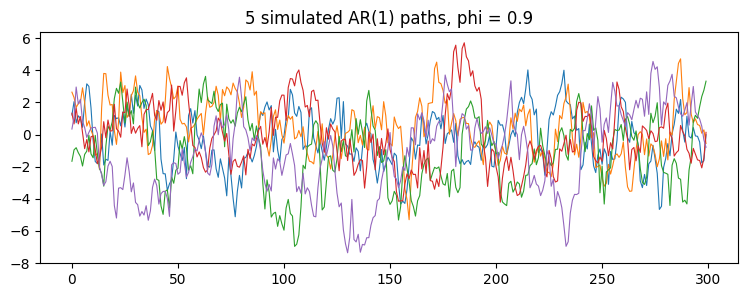

In [44]:
%matplotlib inline
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(x[:300, :5], lw=0.8)
ax.set_title("5 simulated AR(1) paths, phi = 0.9")
plt.show()

## 11. NumPy positional vs pandas aligned

Two Series with overlapping but different labels.

In [45]:
s1 = pd.Series([1., 2., 3.], index=[0, 1, 2])
s2 = pd.Series([10., 20., 30.], index=[1, 2, 3])
print(s1)
print()
print(s2)

0    1.0
1    2.0
2    3.0
dtype: float64

1    10.0
2    20.0
3    30.0
dtype: float64


pandas matches by **label**: labels 0 and 3 exist on one side only → NaN.

In [46]:
s1 - s2

0     NaN
1    -8.0
2   -17.0
3     NaN
dtype: float64

NumPy matches by **position**: element 0 with element 0, and so on.

In [47]:
s1.to_numpy() - s2.to_numpy()

array([ -9., -18., -27.])

**Pitfall:** `to_numpy()` on a frame with mixed dtypes gives an `object` array, which is
slow and breaks numeric functions.

In [48]:
print(df[["temp_c", "wind_ms"]].to_numpy().dtype)
print(df[["time", "temp_c"]].to_numpy().dtype)

float64
object


## Quick reference

| Task | Code |
|---|---|
| sample std | `x.std(ddof=1)` (pandas default) |
| ignore NaN | `np.nanmean(x)` |
| percentiles | `np.percentile(x, [5, 50, 95])` |
| correlation | `np.corrcoef(a, b)[0, 1]` |
| corr matrix by column | `np.corrcoef(X, rowvar=False)` |
| trend line | `slope, icpt = np.polyfit(t, y, 1)` |
| OLS | `beta, *_ = np.linalg.lstsq(X, y, rcond=None)` |
| linear system | `np.linalg.solve(A, b)` |
| matrix multiply | `A @ B` |
| seeded rng | `rng = np.random.default_rng(42)` |
| bootstrap indices | `rng.integers(0, n, n)` |
| Series → array | `s.to_numpy()` |